# 74 - Classifying Gaussian Blobs by Width

**Section:** CNNs | **Prereqs:** `CNNs/CNN_MNIST.ipynb` | **Next:** `CNNs/Discovering_Gaussian_Parameters.ipynb`

The synthetic dataset used by several notebooks in this section: 2-D Gaussian
blobs at random centres, with one of two widths, plus noise. The label is the
width.

**Why this task is a good CNN demonstration.** The blob's *position* is random and
irrelevant; only its *width* matters. A CNN, with its shared kernels, learns 'wide
blob' once and detects it anywhere. A fully connected network would have to learn
the pattern separately at every location - which is the argument of
`FNNs/ShiftedMNIST.ipynb` in a cleaner setting.

**Synthetic data is a good habit generally.** You control the difficulty, you know
the ground truth exactly, and you can generate as much as you want. Debugging a
model on data you constructed is far easier than debugging it on MNIST.

**The decision threshold is `yhat > 0`, not `> 0.5`.** The model emits a raw
logit for `BCEWithLogitsLoss`, and `sigmoid(0) = 0.5` - so zero is the logit-space
equivalent of a half probability. Thresholding logits at 0.5 quietly shifts the
decision boundary and mis-reports accuracy.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Dataset

from sklearn.model_selection import train_test_split

In [ ]:
# A 2-D Gaussian on a grid: exp(-(x^2 + y^2) / 2*sigma^2). Larger sigma = wider
# blob. This is the same function used to build the dataset below.
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)

X, Y = np.meshgrid(x, y)

sigma = 2.0
kernal = np.exp(-(X**2 + Y**2) / (2 * sigma**2)) # Calculate the 2D Gaussian kernel

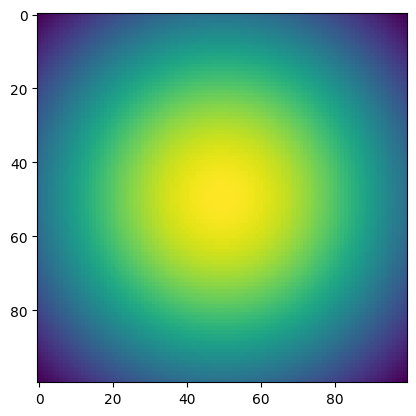

In [ ]:
# The kernel as an image - a bright centre fading outwards.
plt.imshow(kernal.reshape(100,100));

In [ ]:
# meshgrid builds the coordinate grids: X holds each point's x-coordinate, Y its
# y-coordinate, so a formula in X and Y evaluates over the whole grid at once.
np.meshgrid(x, y)

(array([[-2.        , -1.95959596, -1.91919192, ...,  1.91919192,
          1.95959596,  2.        ],
        [-2.        , -1.95959596, -1.91919192, ...,  1.91919192,
          1.95959596,  2.        ],
        [-2.        , -1.95959596, -1.91919192, ...,  1.91919192,
          1.95959596,  2.        ],
        ...,
        [-2.        , -1.95959596, -1.91919192, ...,  1.91919192,
          1.95959596,  2.        ],
        [-2.        , -1.95959596, -1.91919192, ...,  1.91919192,
          1.95959596,  2.        ],
        [-2.        , -1.95959596, -1.91919192, ...,  1.91919192,
          1.95959596,  2.        ]]),
 array([[-2.        , -2.        , -2.        , ..., -2.        ,
         -2.        , -2.        ],
        [-1.95959596, -1.95959596, -1.95959596, ..., -1.95959596,
         -1.95959596, -1.95959596],
        [-1.91919192, -1.91919192, -1.91919192, ..., -1.91919192,
         -1.91919192, -1.91919192],
        ...,
        [ 1.91919192,  1.91919192,  1.91919192, ...,  

# Making Gussians

In [ ]:
# The dataset: 2000 blobs, half with sigma=1.8 and half with sigma=2.4, each at
# a RANDOM centre, plus noise.
# Random centres are the point - the classifier must key on width, not position.
image_size = 91
n_perClass = 1000

x = np.linspace(-4,4,image_size)

X,Y = np.meshgrid(x,x)

sigma = [1.8,2.4]


image = np.zeros((2*n_perClass,1, image_size, image_size), dtype=float)
labels = np.zeros(2*n_perClass)

for i in range(2*n_perClass):

  C = 2*np.random.randn(2) # Creating Random centers

  X_hat = X - C[0]
  Y_hat = Y - C[1]

  G = np.exp(-(X_hat ** 2 + Y_hat**2) / (2*sigma[i%2]))

  noise = np.random.randn(*(G.shape))/5

  #Adding noise
  G += noise

  image[i] = G.reshape(1, image_size,image_size)
  labels[i] = i%2

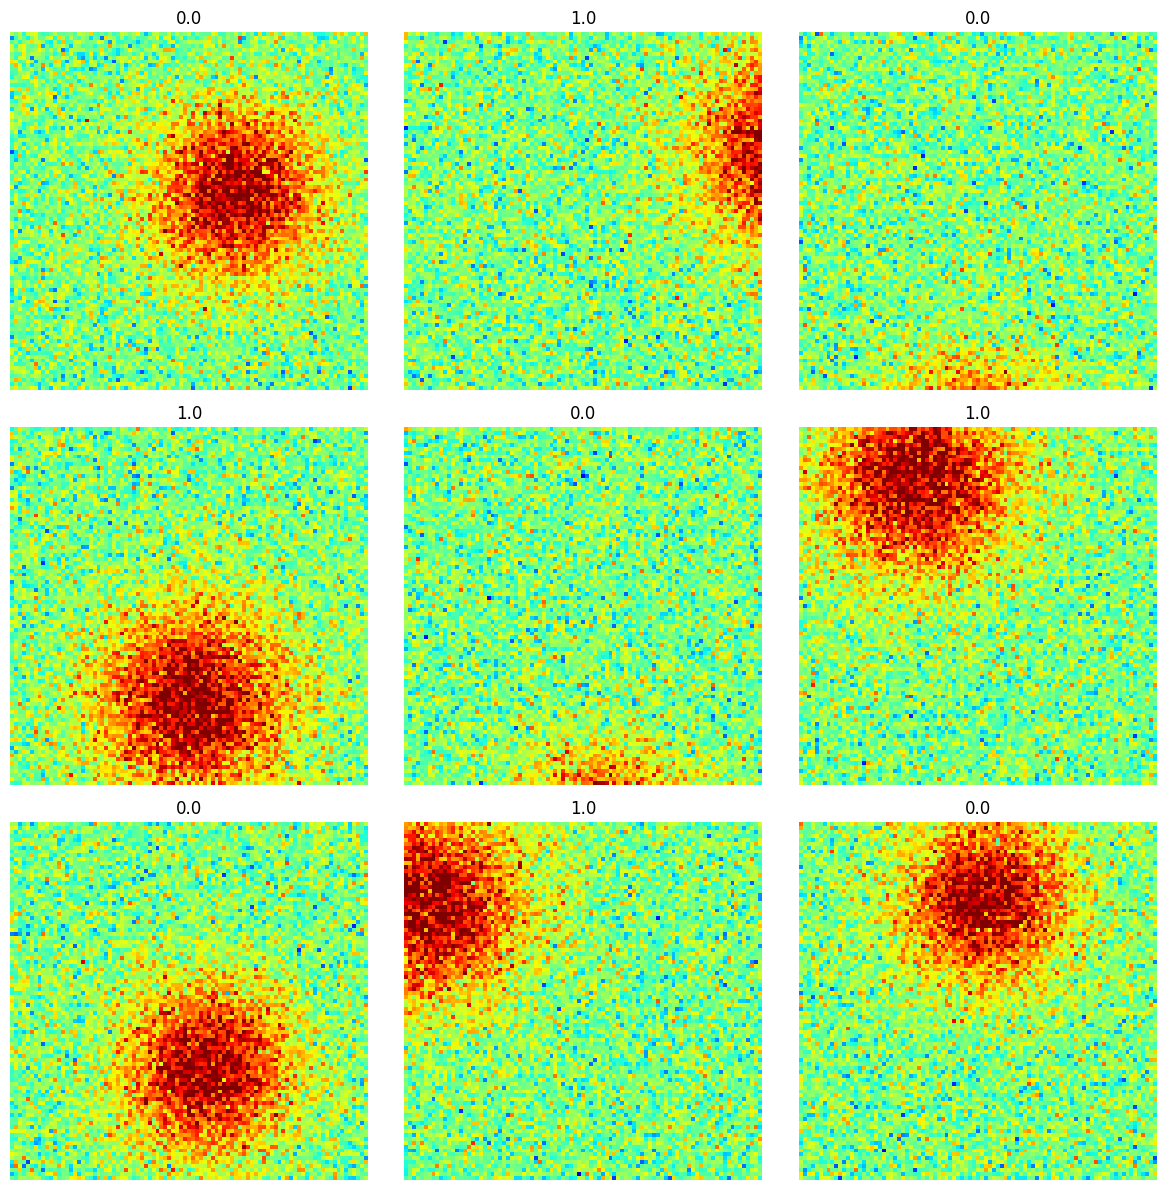

In [ ]:
# Samples from both classes. The difference is subtle by eye, which is what
# makes the model's accuracy meaningful.
fig, ax = plt.subplots(3,3, figsize=(12,12))
ax = ax.flatten()


for i in range(min(2*n_perClass, len(ax))):
  ax[i].imshow(np.squeeze(image[i]), vmin=-1, vmax=1, cmap='jet')
  ax[i].set_title(str(labels[i].item()));
  ax[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Split and loaders. The data is already (N,1,H,W), so no permute is needed.
# Data Loader

device = ('cuda' if torch.cuda.is_available() else 'cpu')
train_data, test_data, train_label, test_label = train_test_split(image, labels, test_size=0.10)

train_tensor = torch.tensor(train_data, dtype=torch.float , device=device)
train_label = torch.tensor(train_label, dtype=torch.long, device=device)

test_tensor = torch.tensor(test_data, dtype=torch.float , device=device)
test_label = torch.tensor(test_label, dtype=torch.long, device=device)

train_dataset = TensorDataset(train_tensor, train_label)
test_dataset = TensorDataset(test_tensor , test_label)

bs = 8
train_loader = DataLoader(train_dataset ,batch_size=bs , drop_last=True, shuffle=True)
test_loder = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0])

In [ ]:
# 1 -> 32 -> 64 -> 128 convs, then global average pooling and a small head.
# Global average pooling matters here beyond convenience: it AVERAGES OVER
# POSITION, discarding where the blob was and keeping only what it looked like -
# exactly the invariance this task needs.
class BlurModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv = nn.Sequential(
        nn.Conv2d(1,32,stride=2,padding=1,kernel_size=3),
        nn.ReLU(),
        nn.MaxPool2d((2,2)),

        nn.Conv2d(32,64, stride=1, padding=1, kernel_size=3),
        nn.ReLU(),
        nn.MaxPool2d((2,2)),

        nn.Conv2d(64,128,stride=1, padding=1, kernel_size=3),
        nn.ReLU(),
        nn.MaxPool2d((2,2)),

        nn.AdaptiveAvgPool2d((1,1))
    )

    self.fc1 = nn.Linear(128,64)
    self.out = nn.Linear(64,1)


  def forward(self,x):

    x = self.conv(x)

    x = x.view(x.size(0), -1)

    x = F.relu(self.fc1(x))

    return self.out(x)


In [ ]:
# torchsummary to check the shapes.
from torchsummary import summary

test_model = BlurModel()
test_model.to(device) # Move the model to the GPU
summary(test_model, input_size=(1,91,91))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 46, 46]             320
              ReLU-2           [-1, 32, 46, 46]               0
         MaxPool2d-3           [-1, 32, 23, 23]               0
            Conv2d-4           [-1, 64, 23, 23]          18,496
              ReLU-5           [-1, 64, 23, 23]               0
         MaxPool2d-6           [-1, 64, 11, 11]               0
            Conv2d-7          [-1, 128, 11, 11]          73,856
              ReLU-8          [-1, 128, 11, 11]               0
         MaxPool2d-9            [-1, 128, 5, 5]               0
AdaptiveAvgPool2d-10            [-1, 128, 1, 1]               0
           Linear-11                   [-1, 64]           8,256
           Linear-12                    [-1, 1]              65
Total params: 100,993
Trainable params: 100,993
Non-trainable params: 0
-------------------------------

In [ ]:
# Training with BCEWithLogitsLoss.
# y.float().unsqueeze(1) reshapes (N,) labels to (N,1) to match the output - BCE
# broadcasts silently otherwise and computes an (N,N) matrix of nonsense.
def model_training():

  model = BlurModel().to(device)


  lossFunc = nn.BCEWithLogitsLoss()
  epochs = 50 # Increased epochs
  optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    )

  losses = []
  train_acc = []
  val_acc = []

  for epoch in range(epochs):

    model.train()

    batch_acc = []
    batch_loss = []

    for x,y in train_loader:
      x = x.to(device)
      y = y.to(device)
      yhat = model(x)

      # Reshape y to match yhat's shape [batch_size, 1] and convert to float
      loss = lossFunc(yhat, y.float().unsqueeze(1))
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()


      acc = 100 * torch.mean( ((yhat > 0) == y.float().unsqueeze(1)).float().detach().cpu())
      batch_acc.append(acc)

    losses.append(np.mean(batch_loss))
    train_acc.append(np.mean(batch_acc))

    # Now validation
    model.eval()
    with torch.no_grad():
      X,Y = next(iter(test_loder))
      X = X.to(device)
      Y = Y.to(device)
      val_acc.append( 100 * torch.mean( ( (model(X) > 0) == Y.float().unsqueeze(1) ).float().detach().cpu() ) )


    if epoch % 10 == 0 or epoch == epochs-1 :
      print(f'Epoch {epoch} | Loss : {losses[epoch]:.4f} | Train Acc {train_acc[epoch]:.2f} | Val Acc : {val_acc[epoch]:.2f}')

  return model, losses, train_acc, val_acc

In [ ]:
model, losses, train_acc, val_acc = model_training()

Epoch 0 | Loss : 0.6906 | Train Acc 51.61 | Val Acc : 48.00
Epoch 10 | Loss : 0.1889 | Train Acc 90.61 | Val Acc : 92.00
Epoch 20 | Loss : 0.1218 | Train Acc 93.61 | Val Acc : 93.00
Epoch 30 | Loss : 0.0995 | Train Acc 94.72 | Val Acc : 94.50
Epoch 40 | Loss : 0.0401 | Train Acc 98.11 | Val Acc : 93.50
Epoch 49 | Loss : 0.0356 | Train Acc 98.28 | Val Acc : 96.00


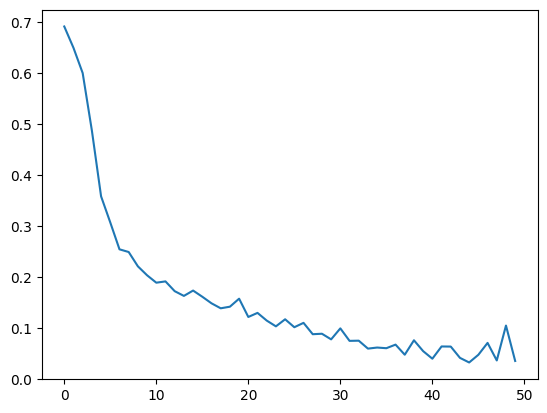

In [ ]:
# Loss curve.
plt.plot(losses);

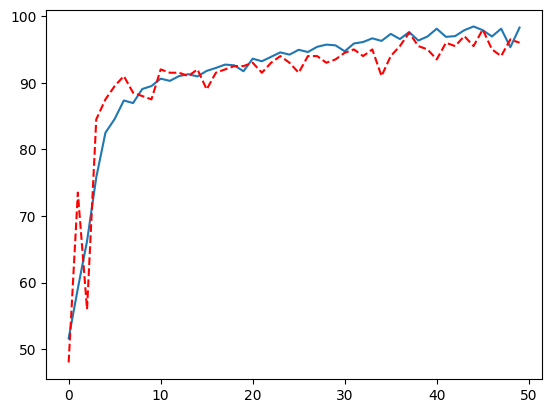

In [ ]:
# Train and validation accuracy. High accuracy on a position-randomised task is
# the evidence that the CNN learned a shape feature rather than locations.
plt.plot(train_acc)
plt.plot(val_acc, 'r--');